# C. Williams post-processed MRRPro ingest and display

This notebook reads one file, a directory, a glob, or a list of hourly post-processed MRRPro files into one chronological `xarray.Dataset`. The configuration cell controls the complete plotting workflow without editing the processing cells.

The default input is the TAMU-CC sample day mounted at `/Volumes/36TB`.

## Installation (`tcsh`)

```tcsh
set WORKSPACE = "$HOME/Desktop/Work/GV Tools"
set PYTHON = "$HOME/anaconda3/bin/python"
$PYTHON -m pip install "$WORKSPACE/gv_tools/release/gv_tools-0.34.0-py3-none-any.whl[netcdf,plot,notebook]"
$PYTHON -m jupyter lab "$WORKSPACE/MRRPro_Postprocessed_Ingest_and_Display.ipynb"
```

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import gv_tools

print("GV Tools version:", gv_tools.__version__)

GV Tools version: 0.34.0


## User configuration

Edit only this cell for normal use. `INPUT_SOURCE` may be a directory, an absolute glob string, one file, or a list of files. Set any plot group to an empty list to skip it. Use `None` for automatic color scaling or the full data time range.

In [2]:
# Input and optional combined-data output
INPUT_SOURCE = Path(os.environ.get(
    "GV_TOOLS_MRRPRO_POSTPROCESSED",
    "/Volumes/36TB/MRR/TAMU-CC/reprocessed/nc_files/nc_files_c01_mom/2023/08/22",
)).expanduser()
OUTPUT_DIRECTORY = Path("~/Desktop/Work/GV Tools/Output/MRRPro").expanduser()
WRITE_COMBINED_NETCDF = False
COMBINED_NETCDF_NAME = "TAMUCC_MRRPro_postprocessed_20230822.nc"

# Select fields and how many figures to create
PLOT_GROUPS = {
    "primary_moments": [
        "reflectivity_factor",
        "radial_velocity",
        "spectrum_width",
    ],
    "spectral_shape_and_snr": [
        "signal_to_noise_ratio",
        "spectrum_skewness",
        "spectrum_kurtosis",
    ],
}

# Per-field appearance. Missing entries fall back to viridis/automatic scaling.
COLORMAPS = {
    "reflectivity_factor": "turbo",
    "radial_velocity": "coolwarm",
    "spectrum_width": "viridis",
    "signal_to_noise_ratio": "magma",
    "spectrum_skewness": "coolwarm",
    "spectrum_kurtosis": "plasma",
}
COLORBAR_BOUNDS = {
    "reflectivity_factor": (-20.0, 40.0),
    "radial_velocity": (-8.0, 8.0),
    "spectrum_width": (0.0, 5.0),
    "signal_to_noise_ratio": (-10.0, 30.0),
    "spectrum_skewness": (-2.0, 2.0),
    "spectrum_kurtosis": (0.0, 10.0),
}
FIELD_LABELS = {
    "reflectivity_factor": "Reflectivity factor (dBZ)",
    "radial_velocity": "Radial velocity (m/s)",
    "spectrum_width": "Spectrum width (m/s)",
    "signal_to_noise_ratio": "Signal-to-noise ratio (dB)",
    "spectrum_skewness": "Spectrum skewness",
    "spectrum_kurtosis": "Spectrum kurtosis",
}

# Spatial and temporal windows
HEIGHT_RANGE_KM = (0.0, 7.0)       # None uses the full instrument range
TIME_RANGE = None                  # Example: ("2023-08-22T12:00", "2023-08-22T18:00")

# Figure-wide controls
COLORBAR_LOCATION = "right"     # left, right, top, or bottom
SHOW_GRID = True
TITLE_PREFIX = "TAMU-CC C. Williams post-processed MRRPro"
FIGURE_WIDTH_INCHES = 15.0
PANEL_HEIGHT_INCHES = 3.4
DPI = 150

# Display and file output may be enabled independently
DISPLAY_FIGURES = True
SAVE_FIGURES = False
IMAGE_FORMAT = "png"            # png, pdf, svg, etc.
TRANSPARENT_BACKGROUND = False
CLOSE_AFTER_DISPLAY = False

## Read the hourly collection

`read_mrr` loads each file, verifies the MRR model, concatenates along `time`, sorts chronologically, and removes duplicate timestamps. The result is independent of the source file handles.

In [3]:
mrr = gv_tools.io.read_mrr(INPUT_SOURCE)
display(mrr)

print("Model:", mrr.attrs.get("mrr_model"))
print("Product:", mrr.attrs.get("mrr_product"))
print("Source files:", mrr.attrs.get("mrr_source_file_count", 1))
print("Time coverage:", mrr.time.values[[0, -1]])
print("Dimensions:", dict(mrr.sizes))

<xarray.Dataset> Size: 53MB
Dimensions:                   (single_value: 1, time: 8640, range: 256)
Coordinates:
  * time                      (time) datetime64[ns] 69kB 2023-08-22T00:00:00....
  * range                     (range) float32 1kB 5.0 40.0 ... 8.93e+03
Dimensions without coordinates: single_value
Data variables: (12/14)
    base_time                 (single_value) datetime64[ns] 8B 2023-08-22
    seconds_since_epoch       (time) datetime64[ns] 69kB 2023-08-22T00:00:00....
    latitude                  (single_value) float32 4B 0.0
    longitude                 (single_value) float32 4B 0.0
    altitude                  (single_value) float32 4B 0.0
    calibration_constant      (single_value) float32 4B -70.5
    ...                        ...
    signal_to_noise_ratio     (time, range) float32 9MB nan nan nan ... nan nan
    reflectivity_factor       (time, range) float32 9MB nan nan nan ... nan nan
    radial_velocity           (time, range) float32 9MB nan nan nan ... nan nan
    spectrum_width            (time, range) float32 9MB nan nan nan ... nan nan
    spectrum_skewness         (time, range) float32 9MB nan nan nan ... nan nan
    spectrum_kurtosis         (time, range) float32 9MB nan nan nan ... nan nan
Attributes:
    source:                 METEK MRRPro Data
    location:               Texas A&M University, Corpus Christi, TX
    history:                created by Christopher Williams on 2024.12.13, us...
    mrr_model:              MRRPro
    mrr_product:            post_processed_moments
    mrr_source_file_count:  24
    mrr_source_files:       /Volumes/36TB/MRR/TAMU-CC/reprocessed/nc_files/nc...

Model: MRRPro
Product: post_processed_moments
Source files: 24
Time coverage: ['2023-08-22T00:00:00.006000000' '2023-08-22T23:59:50.007812500']
Dimensions: {'single_value': 1, 'time': 8640, 'range': 256}


## Inspect available profile fields

This inventory helps when defining custom `PLOT_GROUPS`. Only two-dimensional `time × range` variables can be passed to the time-height plotter.

In [4]:
profile_rows = []
for name, variable in mrr.data_vars.items():
    if set(variable.dims) == {"time", "range"} and variable.ndim == 2:
        values = np.asarray(variable.values, dtype=float)
        finite = np.isfinite(values)
        profile_rows.append({
            "field": name,
            "long_name": variable.attrs.get("long_name", ""),
            "units": variable.attrs.get("units", ""),
            "valid_percent": 100.0 * finite.mean(),
            "minimum": np.nanmin(values) if finite.any() else np.nan,
            "maximum": np.nanmax(values) if finite.any() else np.nan,
        })
field_inventory = pd.DataFrame(profile_rows).set_index("field")
display(field_inventory.style.format({
    "valid_percent": "{:.1f}", "minimum": "{:.3g}", "maximum": "{:.3g}"
}))

,long_name,units,valid_percent,minimum,maximum
field,,,,,
signal_to_noise_ratio,Signal to Noise Ratio. A 5x5 pixel filter has been applied.,dB,31.9,-21.4,41.8
reflectivity_factor,"Calibrated Measured Reflectivity Factor, Zm [dBZ], no attenuation correction. A 5x5 pixel filter has been applied.",dBZ,31.9,-13.5,47.9
radial_velocity,"Mean radial velocity of scatterers, positive values are moving toward the radar. A 5x5 pixel filter has been applied.",m/s,31.9,-4.44,9.58
spectrum_width,"Spectrum width, defined as 2*(sqrt(spectrum variance)). A 5x5 pixel filter has been applied.",m/s,31.9,0.244,2.6
spectrum_skewness,Spectrum skewness. A 5x5 pixel filter has been applied.,-,31.9,-1.47,1.49
spectrum_kurtosis,Spectrum kurtosis. A 5x5 pixel filter has been applied.,-,31.9,1.4,6.29


## Optionally write the combined xarray dataset

Enable `WRITE_COMBINED_NETCDF` in the configuration cell to preserve the complete combined day as a new NetCDF file.

In [5]:
if WRITE_COMBINED_NETCDF:
    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    combined_path = OUTPUT_DIRECTORY / COMBINED_NETCDF_NAME
    mrr.to_netcdf(combined_path)
    print("Combined dataset saved to", combined_path)
else:
    print("Combined NetCDF output is disabled. Set WRITE_COMBINED_NETCDF=True to enable it.")

Combined NetCDF output is disabled. Set WRITE_COMBINED_NETCDF=True to enable it.


## Create configurable time-height displays

Each entry in `PLOT_GROUPS` becomes a separate stacked figure. All field-specific mappings are filtered automatically, so groups may contain any supported subset.

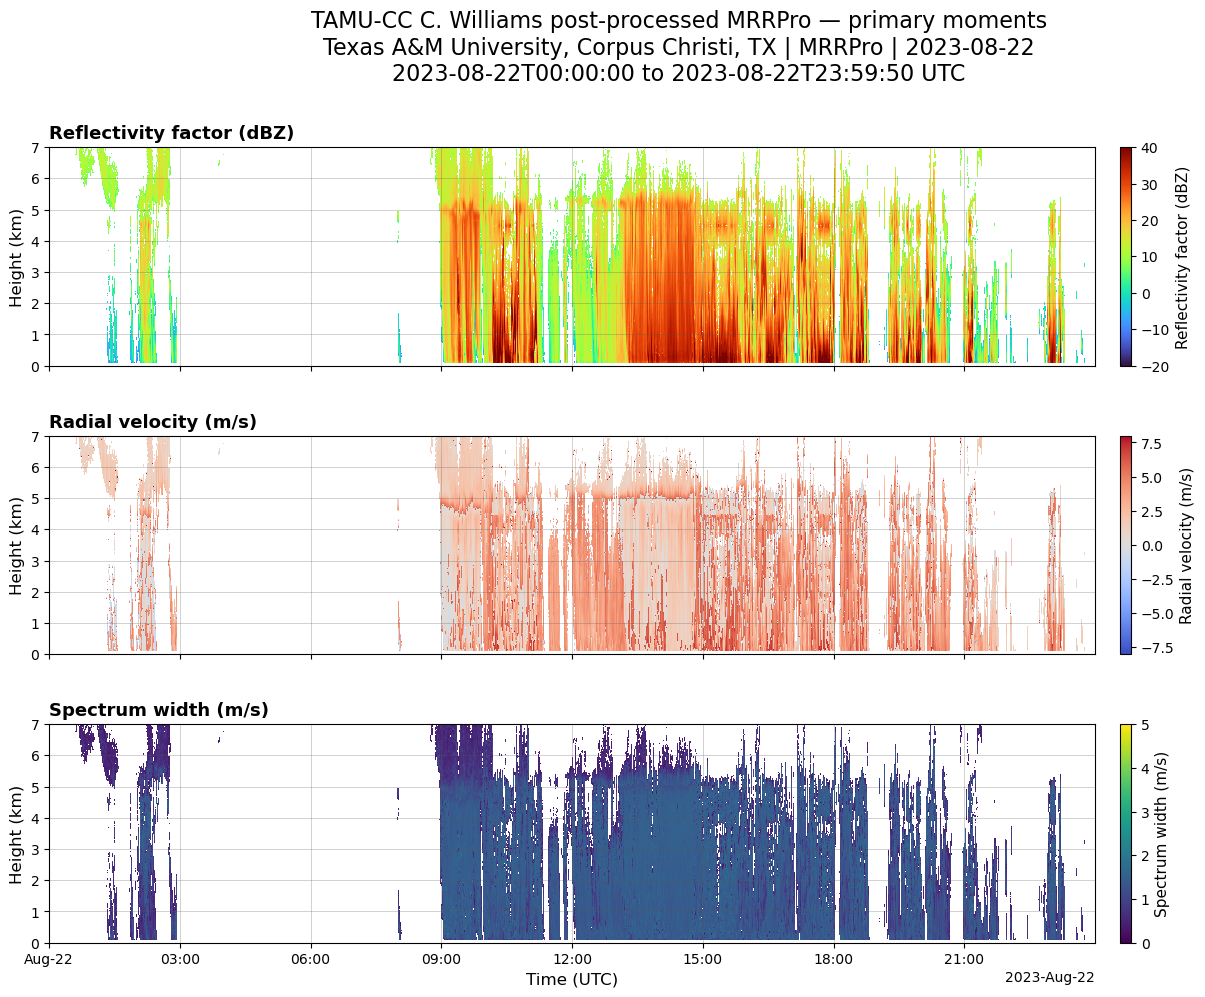

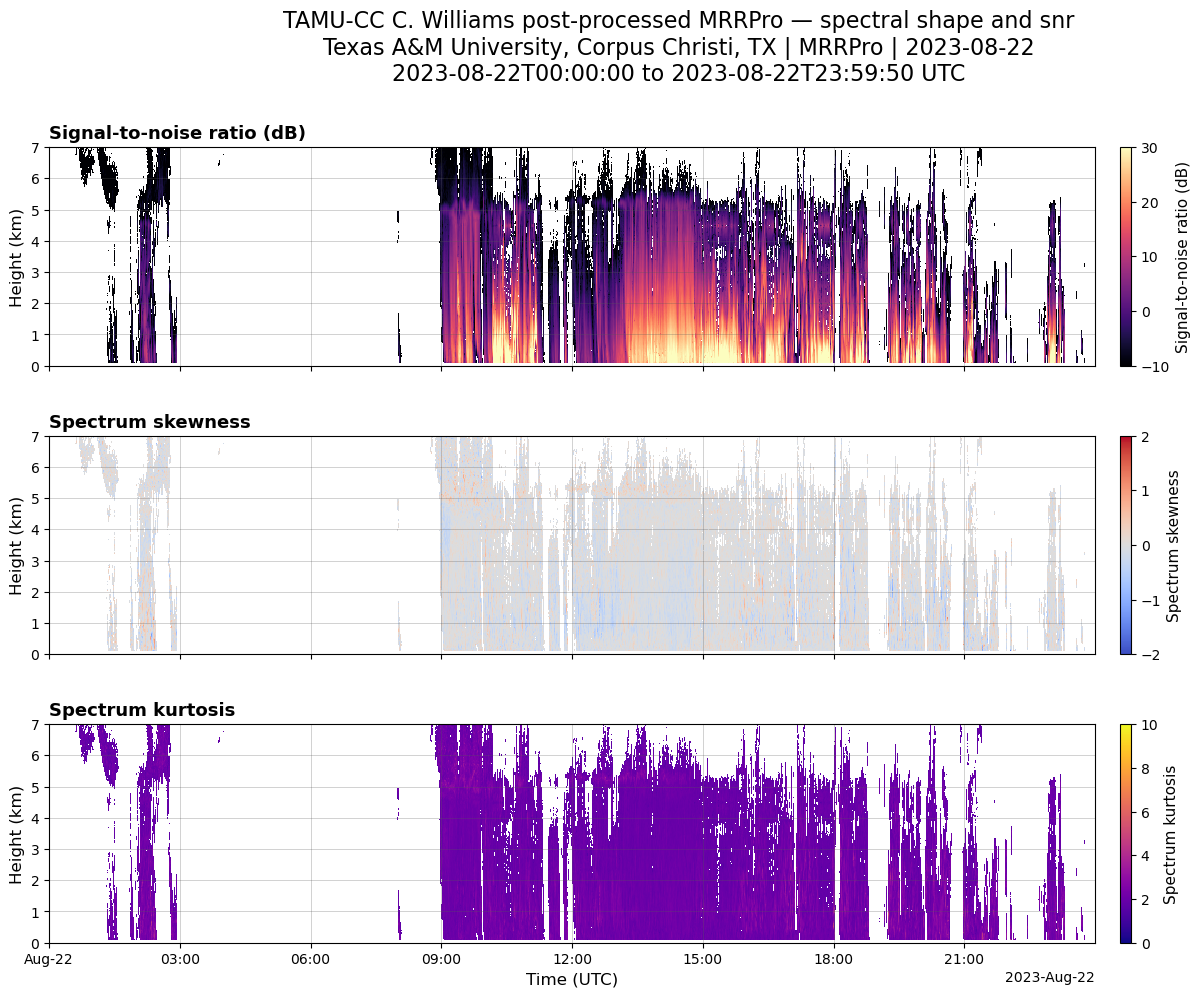

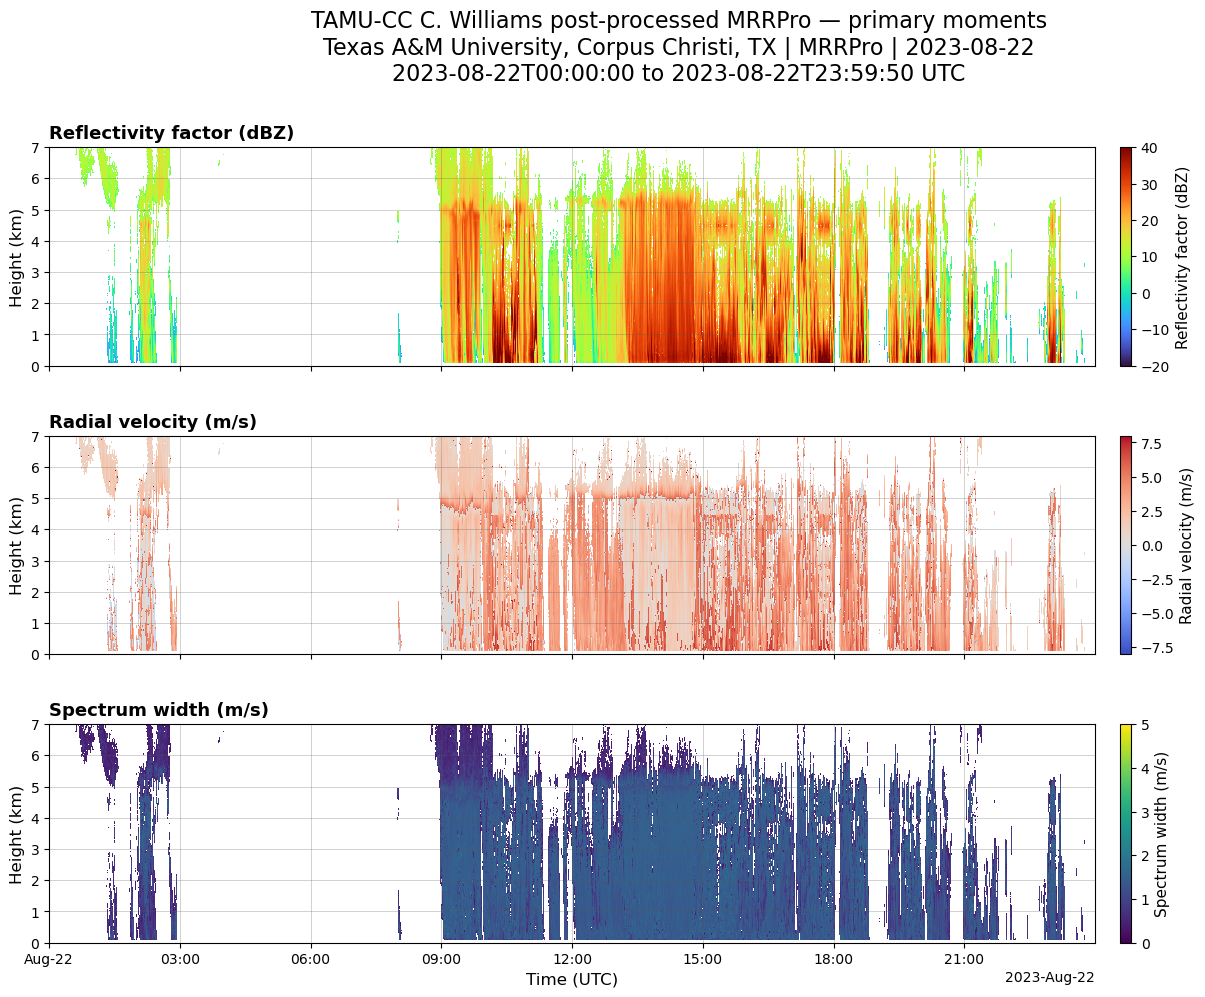

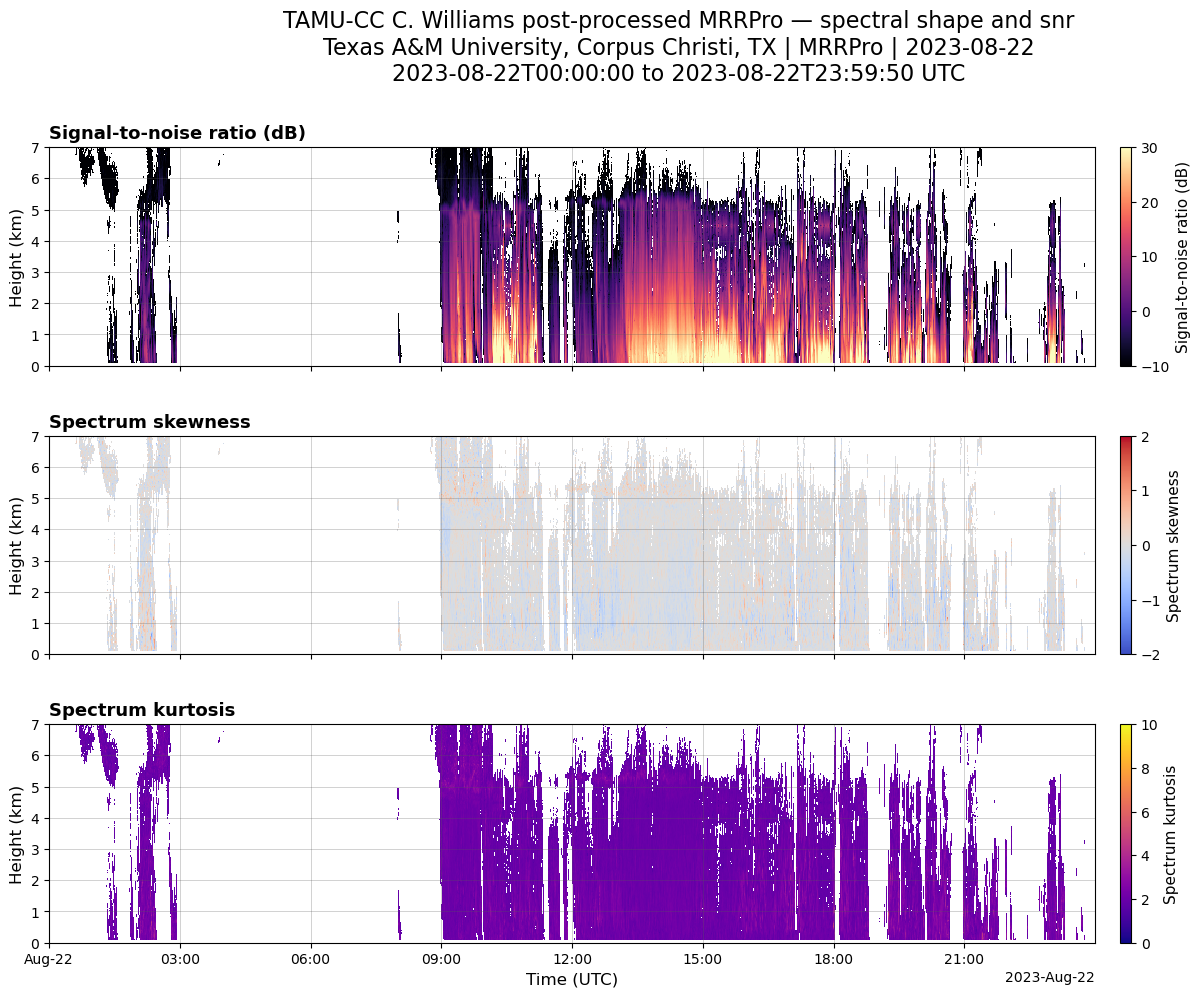

In [6]:
figures = {}
available = set(mrr.data_vars)

for group_name, requested_fields in PLOT_GROUPS.items():
    fields = [name for name in requested_fields if name in available]
    missing = [name for name in requested_fields if name not in available]
    if missing:
        print(f"{group_name}: skipping unavailable fields {missing}")
    if not fields:
        print(f"{group_name}: no fields selected; figure skipped")
        continue

    figure = gv_tools.graph.plot_mrr_time_height_quicklook(
        mrr,
        fields,
        cmaps={name: COLORMAPS.get(name, "viridis") for name in fields},
        colorbar_bounds={name: COLORBAR_BOUNDS[name] for name in fields if name in COLORBAR_BOUNDS},
        field_labels={name: FIELD_LABELS[name] for name in fields if name in FIELD_LABELS},
        height_range_km=HEIGHT_RANGE_KM,
        time_range=TIME_RANGE,
        colorbar_location=COLORBAR_LOCATION,
        grid=SHOW_GRID,
        title=f"{TITLE_PREFIX} — {group_name.replace('_', ' ')}",
        figsize=(FIGURE_WIDTH_INCHES, PANEL_HEIGHT_INCHES * len(fields)),
        dpi=DPI,
    )
    figures[group_name] = figure

    if SAVE_FIGURES:
        OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
        image_path = OUTPUT_DIRECTORY / f"{group_name}.{IMAGE_FORMAT}"
        figure.savefig(
            image_path, dpi=DPI, bbox_inches="tight", transparent=TRANSPARENT_BACKGROUND
        )
        print("Figure saved to", image_path)
    if DISPLAY_FIGURES:
        display(figure)
    if CLOSE_AFTER_DISPLAY or not DISPLAY_FIGURES:
        plt.close(figure)

## Focused time-window example

For a short event, set `TIME_RANGE` in the configuration cell—for example `('2023-08-22T12:00', '2023-08-22T18:00')`—and rerun the plotting cell. You can also create a separate view without changing the global settings:

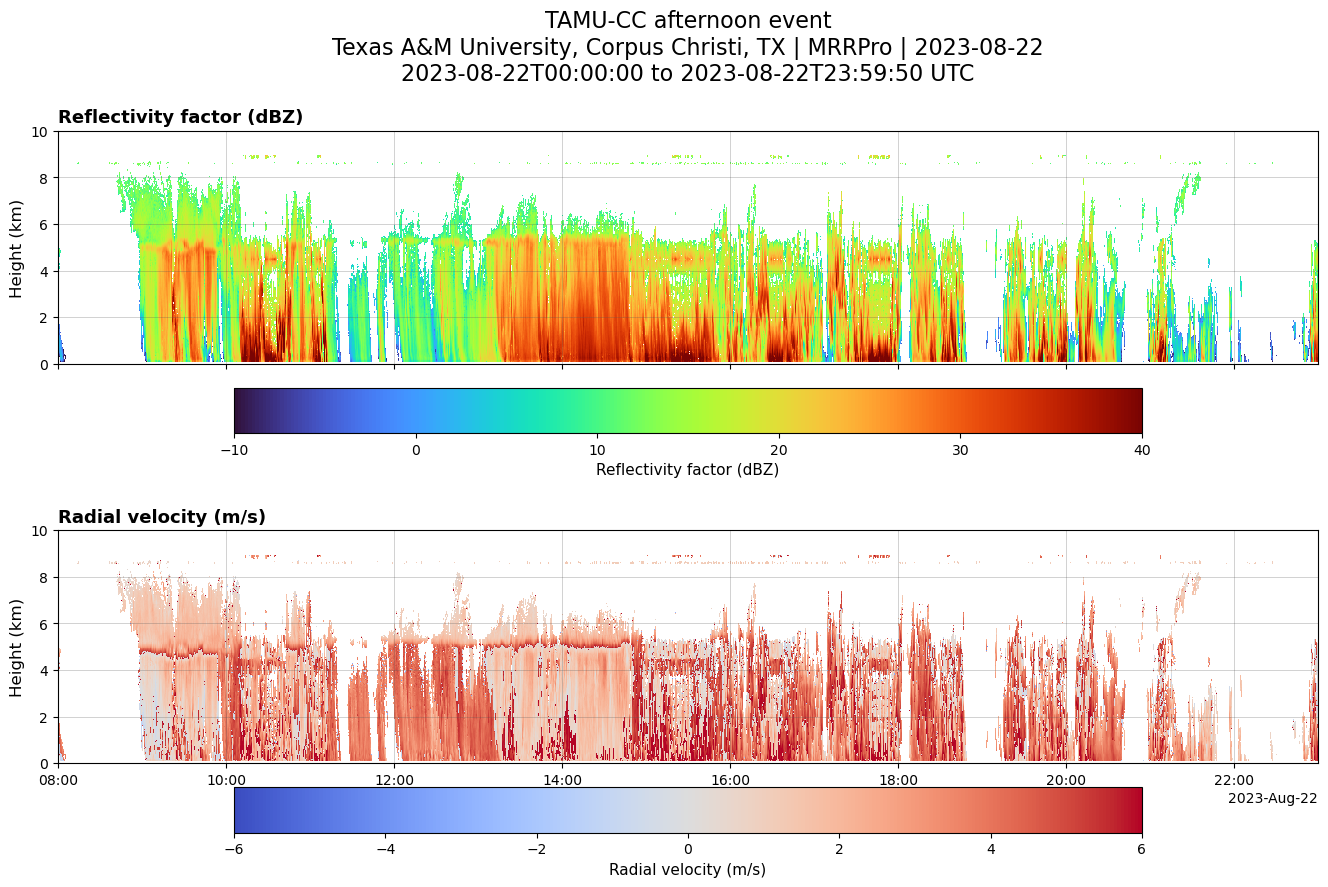

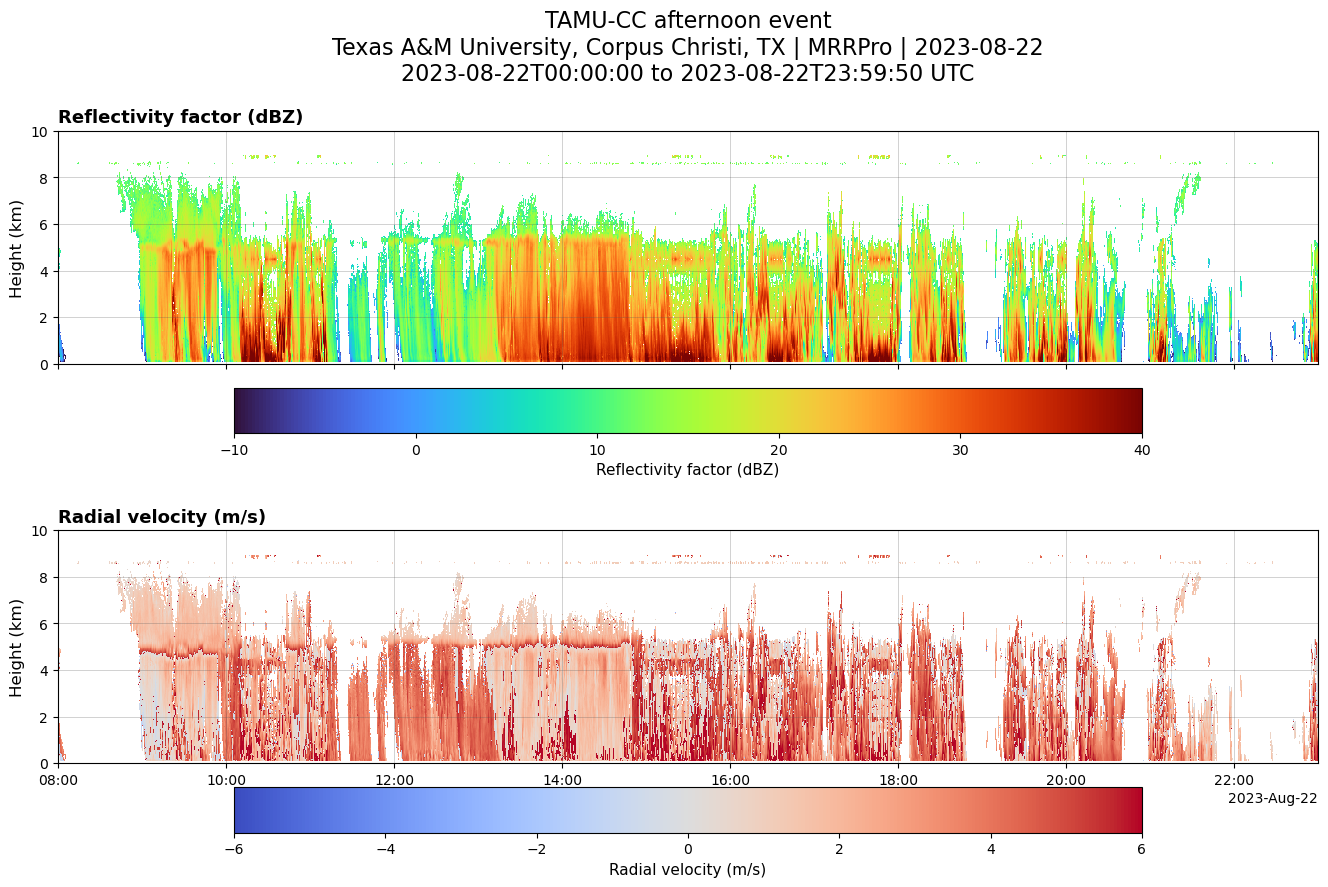

In [10]:
# Uncomment to create an independent event plot.
event_figure = gv_tools.graph.plot_mrr_time_height_quicklook(
    mrr,
    ["reflectivity_factor", "radial_velocity"],
    time_range=("2023-08-22T08:00", "2023-08-22T23:00"),
    height_range_km=(0.0, 10.0),
    cmaps={"reflectivity_factor": "turbo", "radial_velocity": "coolwarm"},
    colorbar_bounds={"reflectivity_factor": (-10, 40), "radial_velocity": (-6, 6)},
    field_labels=FIELD_LABELS,
    colorbar_location="bottom",
    grid=True,
    title="TAMU-CC afternoon event",
    figsize=(15, 9),
    dpi=200,
)
display(event_figure)

In [15]:
mrr['latitude']

<xarray.DataArray 'latitude' (single_value: 1)> Size: 4B
array([0.], dtype=float32)
Dimensions without coordinates: single_value
Attributes:
    long_name:  Degrees North Latitude
    units:      degrees

In [19]:
float(mrr.latitude[0])

0.0

In [21]:
float(mrr.longitude[0])

0.0